# D2C Customer Churn Capstone
## Part 2: RFM Segmentation and Customer Analysis

Author: Prateek Parmar

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# Load datasets

customers = pd.read_csv("../d2c churn data package/customers.csv")
orders = pd.read_csv("../d2c churn data package/orders.csv")

print("Datasets loaded successfully")

Datasets loaded successfully


In [3]:
customers.head()

,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent
0,CUST00001,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes
1,CUST00002,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes
2,CUST00003,2025-03-08,Tier 1,25-34,Influencer,NaN,Skin Care,Oily,Yes
3,CUST00004,2025-04-15,Tier 3,25-34,Google Search,NaN,Fragrance,Normal,No
4,CUST00005,2024-08-21,Tier 3,35-44,Organic,Gold,Hair Care,Combination,Yes


In [4]:
orders.head()

,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
0,ORD000001,CUST00001,2024-08-06,Skin Care,1,540.70,0.43,3,0,4.0
1,ORD000002,CUST00001,2024-10-23,Hair Care,2,467.96,0.64,4,1,1.0
2,ORD000006,CUST00001,2025-01-18,Makeup,1,581.81,0.27,7,0,4.0
3,ORD000005,CUST00001,2025-01-22,Hair Care,1,433.15,0.27,2,0,4.0
4,ORD000004,CUST00001,2025-02-28,Skin Care,1,569.22,0.34,4,0,4.0


In [5]:
customers['signup_date'] = pd.to_datetime(customers['signup_date'])
orders['order_date'] = pd.to_datetime(orders['order_date'])

print(customers.dtypes)
print()
print(orders.dtypes)

customer_id                       str
signup_date            datetime64[us]
city_tier                         str
age_group                         str
acquisition_channel               str
loyalty_tier                      str
preferred_category                str
skin_type                         str
marketing_consent                 str
dtype: object

order_id                    str
customer_id                 str
order_date       datetime64[us]
category                    str
quantity                  int64
gross_amount            float64
discount_pct            float64
delivery_days             int64
returned                  int64
rating                  float64
dtype: object


# RFM Metric Calculation

In [6]:
# Create reference date

reference_date = orders['order_date'].max()

print("Reference Date:", reference_date)

Reference Date: 2025-11-29 00:00:00


In [7]:
# Calculate RFM metrics

rfm = orders.groupby('customer_id').agg({
    'order_date': lambda x: (reference_date - x.max()).days,
    'order_id': 'count',
    'gross_amount': 'sum'
})

# Rename columns
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# Reset index
rfm = rfm.reset_index()

rfm.head()

,customer_id,Recency,Frequency,Monetary
0,CUST00001,167,6,2955.57
1,CUST00002,34,3,1713.10
2,CUST00003,231,1,649.98
3,CUST00004,191,1,1604.04
4,CUST00005,10,6,3910.43


In [8]:
rfm.describe()

,Recency,Frequency,Monetary
count,2400.000000,2400.000000,2400.000000
mean,105.552083,4.170417,3102.366721
std,103.035447,2.626960,2318.314239
min,0.000000,1.000000,149.000000
25%,22.000000,2.000000,1371.697500
50%,55.000000,4.000000,2621.735000
75%,179.250000,6.000000,4253.452500
max,622.000000,17.000000,27920.050000


# RFM Scoring

In [9]:
# Create R, F, M scores

rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])

rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])

rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

rfm.head()

,customer_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,CUST00001,167,6,2955.57,2,4,3
1,CUST00002,34,3,1713.10,4,2,2
2,CUST00003,231,1,649.98,1,1,1
3,CUST00004,191,1,1604.04,2,1,2
4,CUST00005,10,6,3910.43,5,4,4


In [10]:
# Combine RFM scores

rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

rfm.head()

,customer_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,CUST00001,167,6,2955.57,2,4,3,243
1,CUST00002,34,3,1713.10,4,2,2,422
2,CUST00003,231,1,649.98,1,1,1,111
3,CUST00004,191,1,1604.04,2,1,2,212
4,CUST00005,10,6,3910.43,5,4,4,544


# Customer Segmentation

In [11]:
# Create customer segments

def segment_customer(row):

    if row['RFM_Score'] == '555':
        return 'Champions'

    elif row['R_Score'] >= 4 and row['F_Score'] >= 4:
        return 'Loyal Customers'

    elif row['M_Score'] == 5:
        return 'Big Spenders'

    elif row['R_Score'] >= 4:
        return 'Recent Customers'

    elif row['R_Score'] <= 2 and row['F_Score'] >= 4:
        return 'At Risk'

    else:
        return 'Regular Customers'


rfm['Segment'] = rfm.apply(segment_customer, axis=1)

rfm.head()

,customer_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,CUST00001,167,6,2955.57,2,4,3,243,At Risk
1,CUST00002,34,3,1713.10,4,2,2,422,Recent Customers
2,CUST00003,231,1,649.98,1,1,1,111,Regular Customers
3,CUST00004,191,1,1604.04,2,1,2,212,Regular Customers
4,CUST00005,10,6,3910.43,5,4,4,544,Loyal Customers


In [13]:
# Segment distribution

rfm['Segment'].value_counts()

Segment
Regular Customers    1088
Recent Customers      435
Loyal Customers       417
Big Spenders          212
At Risk               146
Champions             102
Name: count, dtype: int64

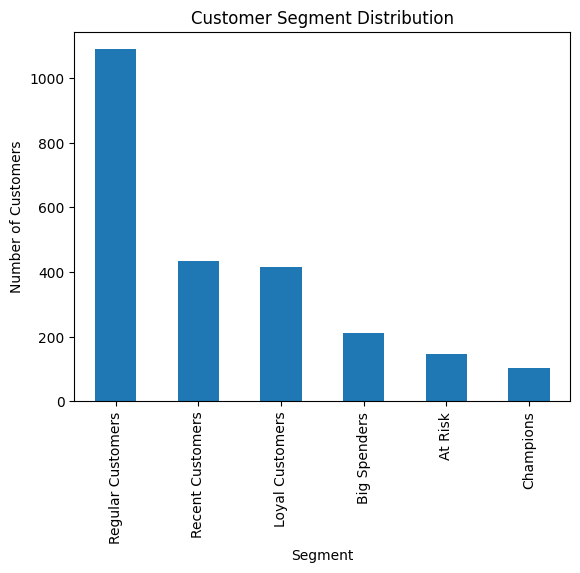

In [14]:
# Segment visualization

rfm['Segment'].value_counts().plot(kind='bar')

plt.title("Customer Segment Distribution")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

plt.show()

In [15]:
# Export customer segments

rfm.to_csv("segments.csv", index=False)

print("segments.csv exported successfully")

segments.csv exported successfully
